In [2]:
import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [4]:
df = pd.read_csv("cleaned.csv")

In [5]:
df.head()

,Name,Industry,Location,Branches,Ratings,Reviews,Salaries,Interviews,jobs,Benifits,Awards
0,TCS,IT Services & Consulting,Hyderabad / Secunderabad,439,3.3,110000.0,990000.0,11900.0,3300.0,10600.0,No Award
1,Accenture,IT Services & Consulting,Hyderabad / Secunderabad,255,3.7,72100.0,650000.0,9200.0,34500.0,6700.0,No Award
2,Wipro,IT Services & Consulting,Hyderabad,371,3.6,64000.0,480000.0,6700.0,4700.0,4600.0,No Award
3,Cognizant,IT Services & Consulting,Hyderabad,232,3.6,60400.0,600000.0,6400.0,552.0,5500.0,No Award
4,Capgemini,IT Services & Consulting,Hyderabad / Secunderabad,182,3.7,52100.0,480000.0,5500.0,2700.0,3700.0,No Award


# 1.Ratings Distribution for each Company

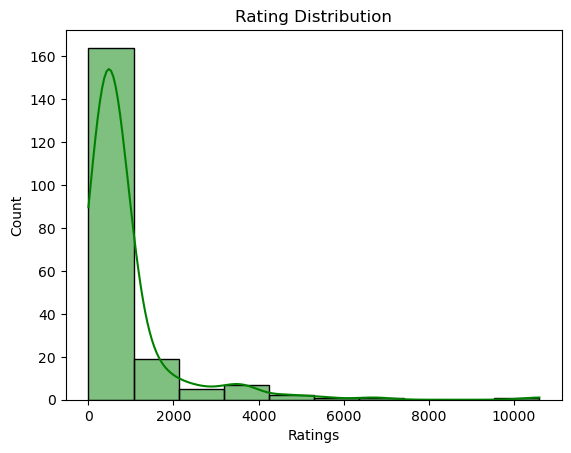

In [123]:
sns.histplot(data = df,x="Benifits", bins = 10,color='green',kde=True)
plt.title("Rating Distribution")
plt.xlabel("Ratings")
plt.ylabel("Count")
plt.show()

In [ ]:
Insight:

Are most companies rated 3–4?

Are there many low-rated companies?

## 2.Instustries of companies

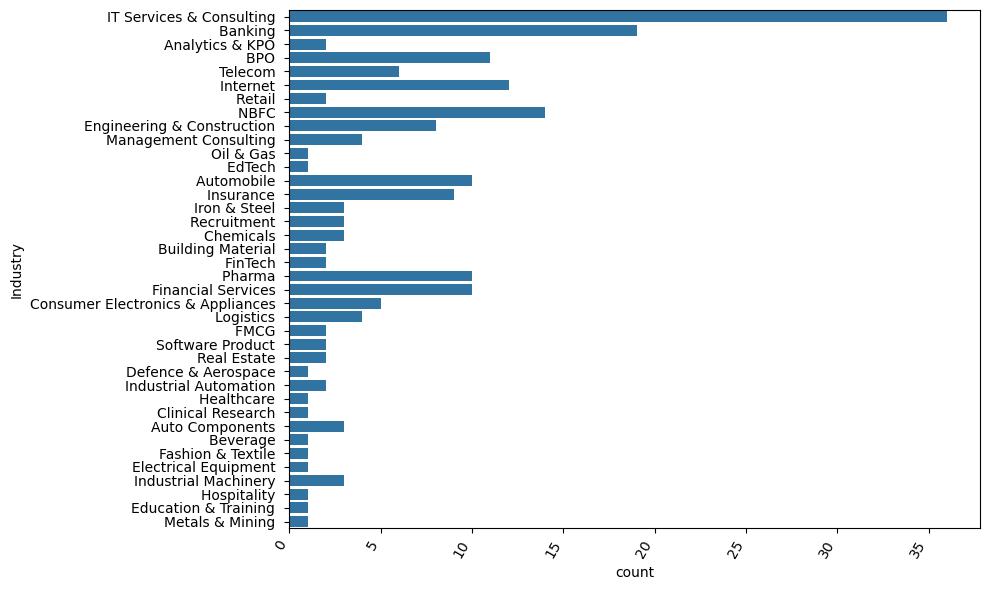

In [61]:
plt.figure(figsize=(10,6))
sns.countplot(y='Industry', data=df)

plt.xticks(rotation=60,ha='right')
plt.tight_layout()
plt.show()

## Hieghest branches(top 10 companies)

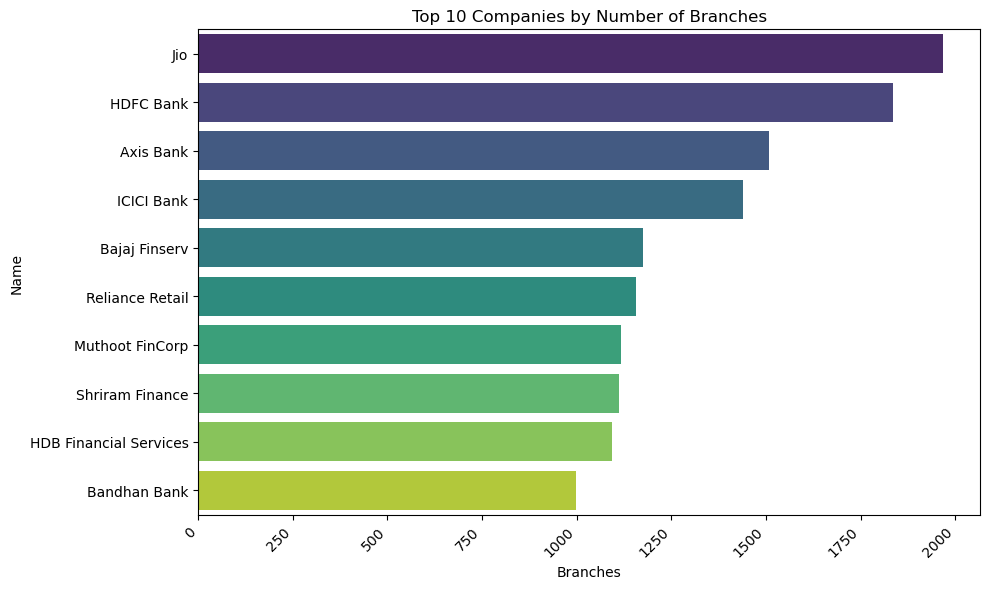

In [66]:
top_10_branches = df.sort_values(by="Branches", ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x="Branches", y="Name", data=top_10_branches, palette="viridis")
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Companies by Number of Branches")
plt.tight_layout()
plt.show()

## Top 5 Highest job Companies

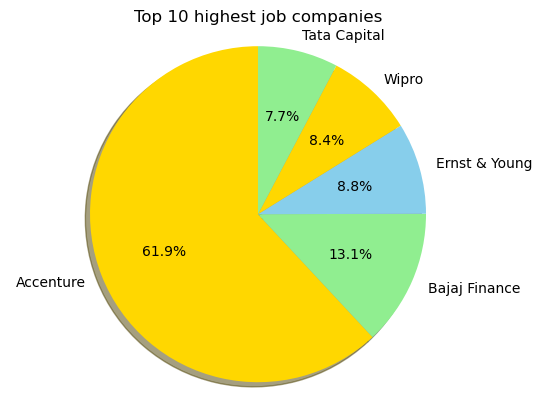

In [29]:
job_reviews = df.sort_values(by="jobs", ascending=False).head()
plt.pie(job_reviews["jobs"], labels=job_reviews["Name"], autopct = '%1.1f%%', startangle = 90, colors = ['gold', 'lightgreen', 'skyblue'], shadow = True)
plt.title("Top 10 highest job companies")
plt.axis('equal')
plt.show()        

## Reviews 

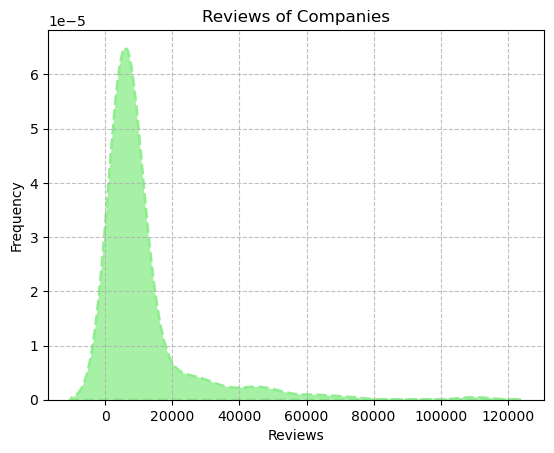

In [33]:
sns.kdeplot(data = df,
            x = "Reviews",
            color = "lightgreen",
            linestyle = '--',
            linewidth = 2,
            fill = True,
            alpha = 0.8
           )
#plt.xlim(0,10000)
plt.title("Reviews of Companies")
plt.xlabel("Reviews")
plt.ylabel("Frequency")
plt.grid(True, linestyle='--', alpha = 0.8)
plt.show()

## Benifits Frenquency

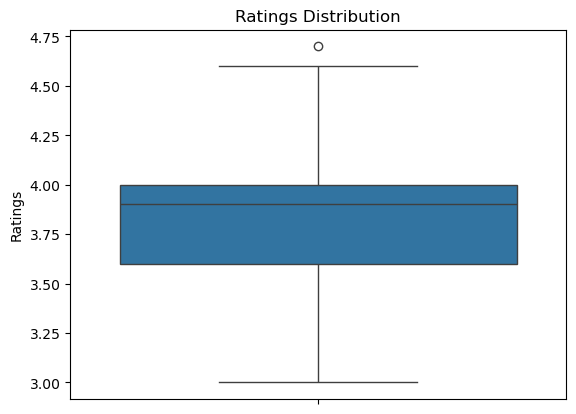

In [117]:

sns.boxplot(y="Ratings", data= df)
plt.title("Ratings Distribution")
plt.show()



<Axes: xlabel='Reviews', ylabel='Ratings'>

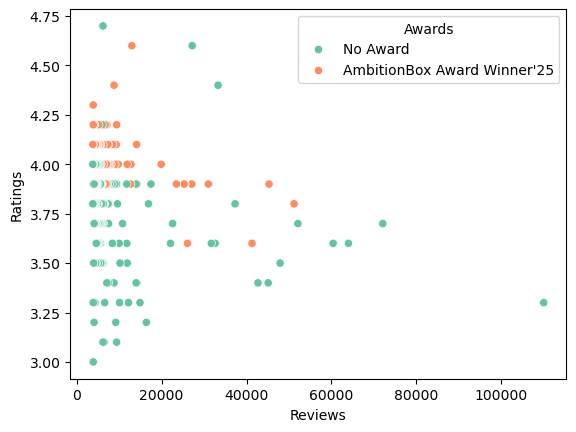

In [52]:
sns.scatterplot(
    x = 'Reviews',
    y = 'Ratings',
    data = df,
    hue = 'Awards', # coloe by category(male/female)
    palette = 'Set2'
)

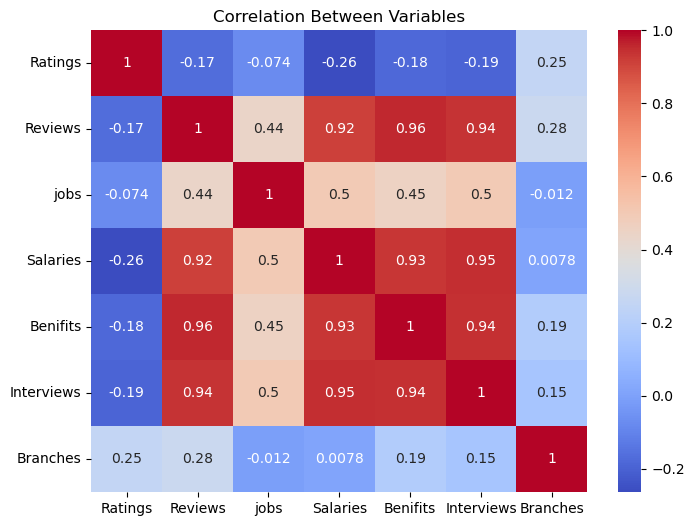

In [54]:
plt.figure(figsize=(8,6))

corr = df[["Ratings","Reviews","jobs","Salaries","Benifits","Interviews","Branches"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Between Variables")
plt.show()

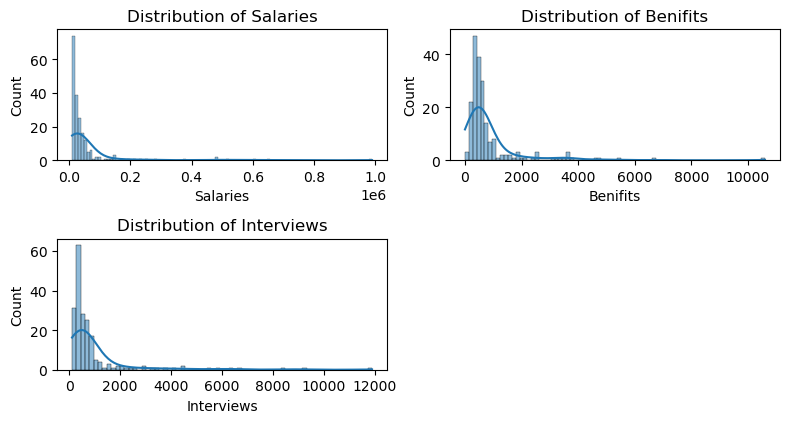

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ["Salaries", "Benifits", "Interviews"]

plt.figure(figsize=(8,6))

for i, col in enumerate(cols, 1):
    plt.subplot(3,2,i)
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

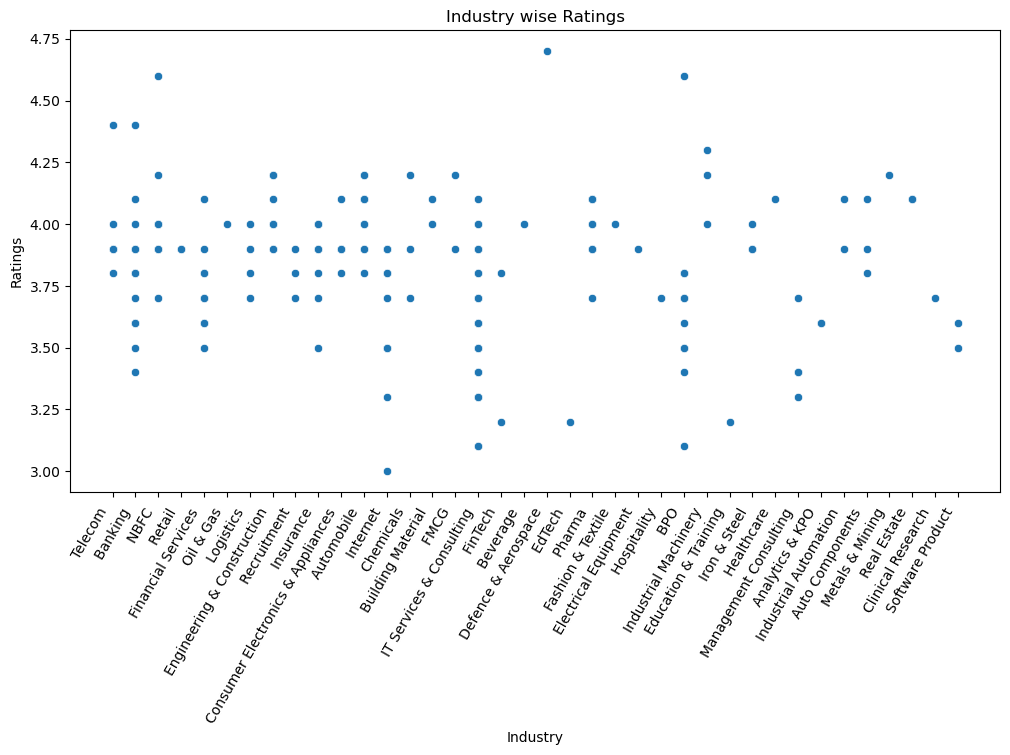

In [106]:
## Top 10 Highest rated Companies
top_10 = df.sort_values(by="Branches", ascending= False)
top_10
plt.figure(figsize=(12,6))
sns.scatterplot(data=top_10,
            x=top_10["Industry"],
            y=top_10["Ratings"],
            palette = "Set2"
           )
plt.title("Industry wise Ratings")
plt.xticks(rotation=60,ha='right')
plt.show()


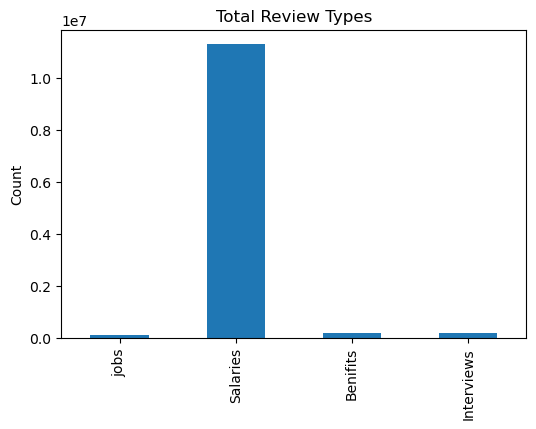

In [86]:
review_types = df[["jobs","Salaries","Benifits","Interviews"]].sum()

review_types.plot(
    kind="bar",
    stacked=True,
    figsize=(6,4)
)

plt.title("Total Review Types")
plt.ylabel("Count")
plt.show()


In [87]:
review_types

jobs            102525.0
Salaries      11297300.0
Benifits        175814.0
Interviews      194464.0
dtype: float64

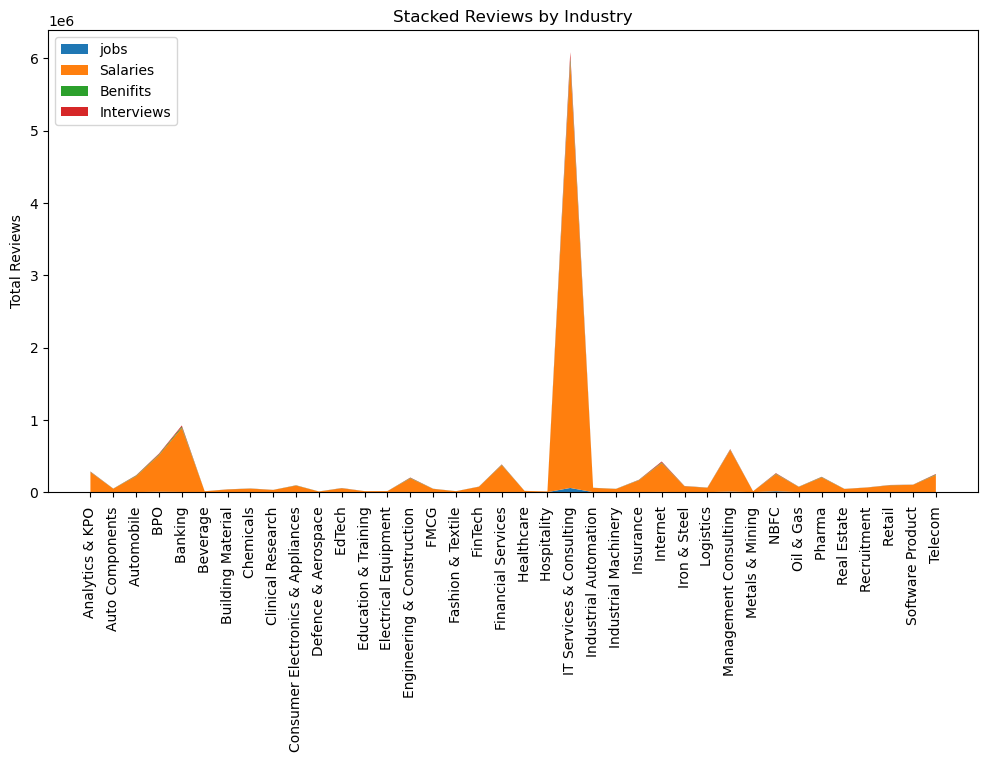

In [124]:
Name_data = df.groupby("Name")[["jobs","Salaries","Benifits","Interviews"]].sum()

x = Name_data.index

plt.figure(figsize=(12,6))

plt.stackplot(
    x,
    Name_data["jobs"],
    Name_data["Salaries"],
    Name_data["Benifits"],
    Name_data["Interviews"],
    labels=["jobs","Salaries","Benifits","Interviews"]
)

plt.xticks(rotation=90)
plt.legend(loc="upper left")
plt.title("Stacked Reviews by Industry")
plt.ylabel("Total Reviews")

plt.show()

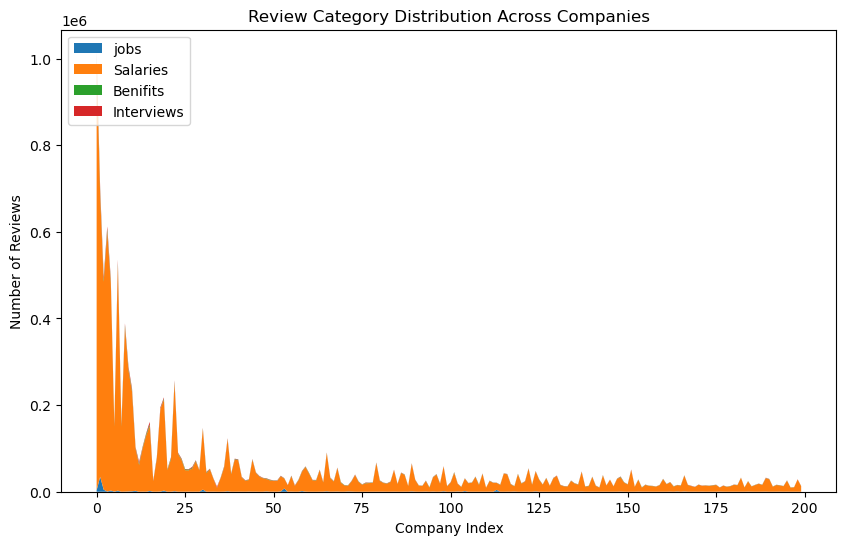

In [90]:
x = df.index

plt.figure(figsize=(10,6))

plt.stackplot(
    x,
    df["jobs"],
    df["Salaries"],
    df["Benifits"],
    df["Interviews"],
    labels=["jobs","Salaries","Benifits","Interviews"]
)

plt.legend(loc="upper left")
plt.title("Review Category Distribution Across Companies")
plt.xlabel("Company Index")
plt.ylabel("Number of Reviews")

plt.show()

In [107]:
industry_data


,jobs,Salaries,Benifits,Interviews
Industry,,,,
Analytics & KPO,2700.0,274500.0,4299.0,4697.0
Auto Components,73.0,47700.0,1320.0,947.0
Automobile,1035.0,219800.0,7414.0,5192.0
BPO,5004.0,507600.0,10623.0,9958.0
Banking,2639.0,885600.0,17346.0,16629.0
Beverage,46.0,12100.0,321.0,348.0
Building Material,32.0,37400.0,886.0,1067.0
Chemicals,191.0,48200.0,1516.0,1533.0
Clinical Research,34.0,30900.0,524.0,551.0


In [108]:
top_10 = df.sort_values(by="Branches", ascending= False)
top_10
plt.figure(figsize=(12,6))
sns.scatterplot(data=industry_data,
            x=industry_data["Industry"],
            y=top_10["Ratings"],
            palette = "Set2"
           )
plt.title("Industry wise Ratings")
plt.xticks(rotation=60,ha='right')
plt.show()

KeyError: 'Industry'

<Figure size 1200x600 with 0 Axes>

In [133]:
df["Total_Reviews"] = df[["jobs","Salaries","Benifits","Interviews"]].sum(axis=1)
df["Total_Reviews"]

0      1015800.0
1       700400.0
2       496000.0
3       612452.0
4       491900.0
         ...    
195      26327.0
196      10085.0
197      10500.0
198      28781.0
199      13250.0
Name: Total_Reviews, Length: 200, dtype: float64

In [132]:
Name_data

,jobs,Salaries,Benifits,Interviews
Name,,,,
AU Small Finance Bank,168.0,29300.0,577.0,686.0
Aakash Educational Services,64.0,13800.0,212.0,373.0
Accenture,34500.0,650000.0,6700.0,9200.0
Access Healthcare,1600.0,28800.0,347.0,399.0
Aditya Birla Fashion and Retail,76.0,13300.0,391.0,268.0
...,...,...,...,...
Yes Bank,197.0,43300.0,608.0,551.0
Zydus Lifesciences,30.0,20000.0,605.0,428.0
eClerx,429.0,32400.0,555.0,635.0


In [134]:
df.head()

,Name,Industry,Location,Branches,Ratings,Reviews,Salaries,Interviews,jobs,Benifits,Awards,Total_Reviews
0,TCS,IT Services & Consulting,Hyderabad / Secunderabad,439,3.3,110000.0,990000.0,11900.0,3300.0,10600.0,No Award,1015800.0
1,Accenture,IT Services & Consulting,Hyderabad / Secunderabad,255,3.7,72100.0,650000.0,9200.0,34500.0,6700.0,No Award,700400.0
2,Wipro,IT Services & Consulting,Hyderabad,371,3.6,64000.0,480000.0,6700.0,4700.0,4600.0,No Award,496000.0
3,Cognizant,IT Services & Consulting,Hyderabad,232,3.6,60400.0,600000.0,6400.0,552.0,5500.0,No Award,612452.0
4,Capgemini,IT Services & Consulting,Hyderabad / Secunderabad,182,3.7,52100.0,480000.0,5500.0,2700.0,3700.0,No Award,491900.0


Review_Level
Low     193
Mid       5
High      2
Name: count, dtype: int64

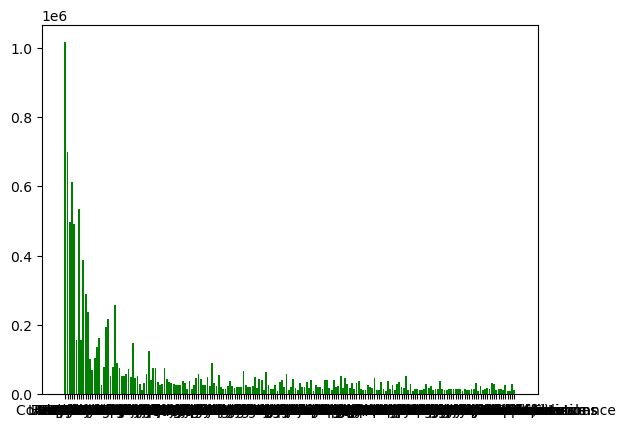

In [144]:
x="Name"
y="Total_Reviews"
plt.bar(x, y,data = df, color="green")
sorted_Reviews = df.sort_values(by="Total_Reviews", ascending = False)
sorted_Reviews

sorted_Reviews["Review_Level"] = pd.cut(
    sorted_Reviews["Total_Reviews"],
    bins=3,
    labels=["Low","Mid","High"]
)
sorted_Reviews[["Total_Reviews","Review_Level"]]
sorted_Reviews["Review_Level"].value_counts()

## 

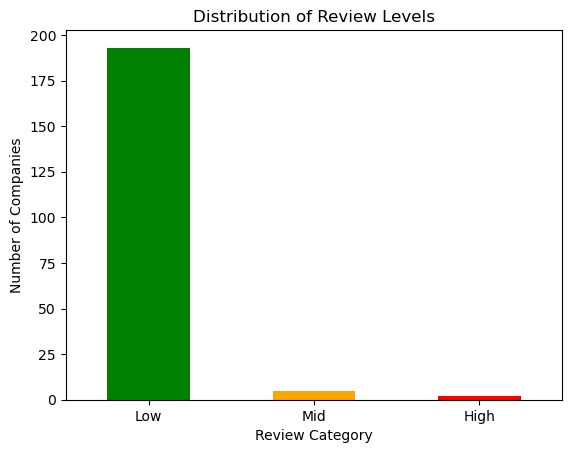

In [147]:
x="Name"
y="Review_Level"
plt.bar(x,y,data=df,color="green")

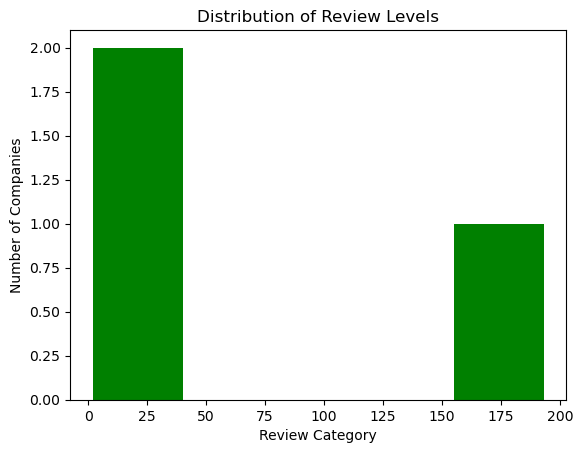

In [153]:
counts = sorted_Reviews["Review_Level"].value_counts()

# Plot bar chart
plt.hist(counts,bins=5, color=["green"])

plt.title("Distribution of Review Levels")
plt.xlabel("Review Category")
plt.ylabel("Number of Companies")
plt.xticks(rotation=0)

plt.show()